# Distinctive terms in **Debias Details** (contrastive TF–IDF)

Each non-empty *Debias Details* cell is one document (debiasing corpus). We compare it to a **background** corpus: *Topic*, *Conclusions*, *Data Details*, and *Note* for every row—so we surface language specific to debiasing write-ups, not generic catalog text.

For each token, **distinctiveness** = mean TF–IDF in debias docs minus mean TF–IDF in background docs (higher = more characteristic of Debias Details).

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer

_here = Path.cwd()
for _papers in (_here / "data" / "papers.csv", _here.parent / "data" / "papers.csv"):
    if _papers.is_file():
        PAPERS_CSV = _papers.resolve()
        break
else:
    raise FileNotFoundError(
        "Could not find data/papers.csv. Set the notebook kernel's working directory to the repo root (viz/) or to debiasing/."
    )

REPO_ROOT = PAPERS_CSV.parent.parent
CHART_PATH = REPO_ROOT / "debiasing" / "debias_distinctive_terms.png"

TOP_N = 28
MIN_DF = 1
MAX_DF = 0.92
MAX_NGRAM = 1  # use 2 to include bigrams

PAPERS_CSV, CHART_PATH

(PosixPath('/Users/josh/Desktop/harvard/kempner/viz/data/papers.csv'),
 PosixPath('/Users/josh/Desktop/harvard/kempner/viz/debiasing/debias_distinctive_terms.png'))

In [2]:
def _background_text(row: pd.Series) -> str:
    parts = []
    for col in ("Topic", "Conclusions", "Data Details", "Note"):
        v = row.get(col, "")
        if pd.isna(v):
            continue
        s = str(v).strip()
        if s:
            parts.append(s)
    return "\n".join(parts)


def distinctive_terms(
    df: pd.DataFrame,
    *,
    top_n: int = 30,
    min_df: int = 1,
    max_df: float = 0.92,
    ngram_max: int = 1,
) -> pd.DataFrame:
    debias_col = "Debias Details"
    mask = df[debias_col].fillna("").astype(str).str.strip().ne("")
    debias_docs = df.loc[mask, debias_col].astype(str).str.strip().tolist()
    if not debias_docs:
        raise ValueError("No non-empty rows in column 'Debias Details'.")

    background_docs = [_background_text(row) for _, row in df.iterrows()]
    background_docs = [t if t.strip() else "(empty)" for t in background_docs]

    corpus = debias_docs + background_docs
    n_debias = len(debias_docs)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        min_df=min_df,
        max_df=max_df,
        ngram_range=(1, min(ngram_max, 2)),
        sublinear_tf=True,
    )
    X = vectorizer.fit_transform(corpus)
    feature_names = np.array(vectorizer.get_feature_names_out())

    X_pos = X[:n_debias]
    X_neg = X[n_debias:]
    mean_pos = np.asarray(X_pos.mean(axis=0)).ravel()
    mean_neg = np.asarray(X_neg.mean(axis=0)).ravel()
    delta = mean_pos - mean_neg

    order = np.argsort(-delta)[:top_n]
    return pd.DataFrame(
        {
            "term": feature_names[order],
            "mean_tfidf_debias": mean_pos[order],
            "mean_tfidf_background": mean_neg[order],
            "distinctiveness": delta[order],
        }
    )

In [3]:
df = pd.read_csv(PAPERS_CSV)
n_debias = int(df["Debias Details"].fillna("").astype(str).str.strip().ne("").sum())
result = distinctive_terms(
    df,
    top_n=TOP_N,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_max=MAX_NGRAM,
)

display(
    result.style.format(
        {
            "mean_tfidf_debias": "{:.4f}",
            "mean_tfidf_background": "{:.4f}",
            "distinctiveness": "{:.4f}",
        }
    ).hide(axis="index")
)

term,mean_tfidf_debias,mean_tfidf_background,distinctiveness
prompting,0.0765,0.0056,0.0709
shot,0.0704,0.0000,0.0704
zero,0.0480,0.0000,0.0480
trained,0.0516,0.0044,0.0472
methods,0.0408,0.0061,0.0347
strategies,0.0320,0.0000,0.0320
technique,0.0313,0.0000,0.0313
sdoh,0.0301,0.0036,0.0265
debiasing,0.0289,0.0026,0.0262
different,0.0501,0.0245,0.0256


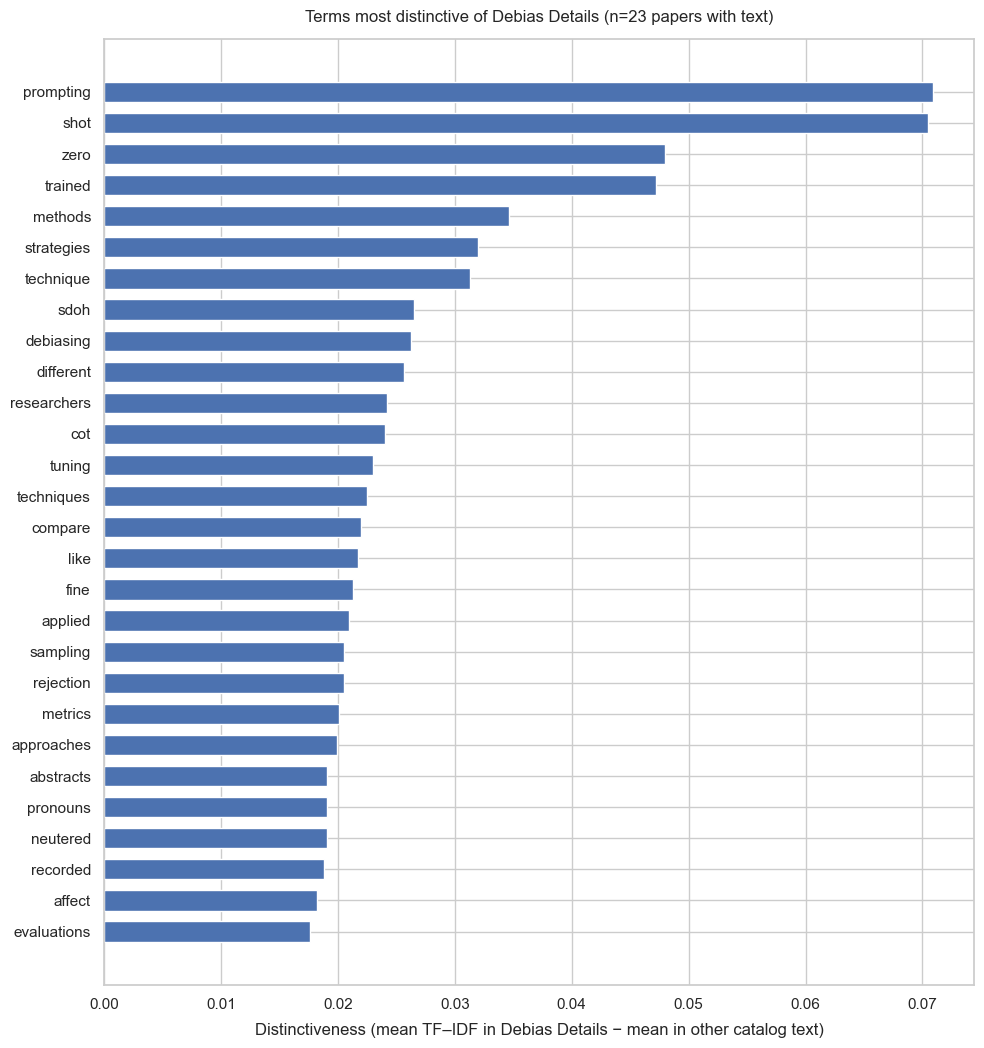

Saved: /Users/josh/Desktop/harvard/kempner/viz/debiasing/debias_distinctive_terms.png


In [4]:
plot_df = result.iloc[::-1].reset_index(drop=True)
sns.set_theme(style="whitegrid", context="notebook")
fig_h = max(4.0, 0.38 * len(plot_df))
fig, ax = plt.subplots(figsize=(10, fig_h))
ax.barh(plot_df["term"], plot_df["distinctiveness"], color="#4c72b0", height=0.65)
ax.set_xlabel(
    "Distinctiveness (mean TF–IDF in Debias Details − mean in other catalog text)",
    labelpad=8,
)
ax.set_title(f"Terms most distinctive of Debias Details (n={n_debias} papers with text)", pad=12)
plt.tight_layout()
CHART_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(CHART_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {CHART_PATH}")